# IOD_lifecycle: temporal evolution of SST anomalies in the central equatorial Pacific
Computes the temporal root mean square error (RMSE) of the Dipole Mode Index (gradient between the western equatorial Indian Ocean (50E-70E and 10S-10N) and the south eastern equatorial Indian Ocean (90E-110E and 10S-0N)) between model and observations. The analysis spans 6 years centred on IOD peak years to evaluate the ability of the model to capture the full lifecycle of IOD events, including onset, peak, and sepay phases.

# Datasets Used for Temporal Evolution Comparison¶
The following reference datasets are employed to evaluate the IOD lifecycle in model simulations:

TropFlux (1979–2018): The primary dataset for comparison, offering accurate surface fluxes and anomalies for tropical climate studies.
Additional datasets include:
20CRv2 (1871–2012): A historical reanalysis dataset reconstructing global atmospheric conditions using surface pressure observations.
ERA-Interim (1979–2018): A widely used reanalysis product providing consistent, high-resolution estimates of atmospheric and surface variables.
ERSSTv5 (1854–2018): A globally gridded SST anomaly dataset optimised for long-term climate monitoring and iod analysis.
HadISST (1870–2018): A comprehensive dataset of SST and sea ice, blending historical observations with reconstructions.
NCEP2 (1979–2018): A second-generation reanalysis dataset delivering improved global atmospheric and surface data.

In [1]:
from esmvalcore.dataset import Dataset

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/esmvalcore/config/_config_object.py:639: ESMValCoreDeprecationWarning: Usage of the single configuration file ~/.esmvaltool/config-user.yml or specifying it via CLI argument `--config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please run `mkdir -p ~/.config/esmvaltool && mv /home/548/cxc548/.esmvaltool/config-user.yml ~/.config/esmvaltool` (or alternatively use a custom `--config_dir`) and omit `--config_file`.
  config_obj.reload()
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:405: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, rem

In [2]:
model_ctrldatasets = {
"ACCESS-ESM1-5": 
    Dataset(
    short_name='ts',
    project='CMIP6',
    mip="Amon",
    exp="piControl",
    ensemble="r1i1p1f1",
    timerange="09000101/11000101",
    dataset="ACCESS-ESM1-5",
    grid="gn"
)}

obs_datasets = {
"HadISST": 
    Dataset(
    short_name='ts',
    dataset='HadISST',
    mip="Amon",
    project='OBS',
    type='reanaly',
    tier=2),
# "ERA-Interim": 
#     Dataset(
#     short_name='tos',
#     dataset='ERA-Interim',
#     mip="Omon",
#     project='OBS',
#     type='reanaly',
#     timerange="19790101/20190101",
#     tier=3)
}

In [3]:

for name, dataset in model_ctrldatasets.items():
    dataset.add_supplementary(short_name='sftlf', mip="fx")
    dataset.add_supplementary(short_name="areacella", mip="fx")

In [4]:
model_ctrldatasets = {name: dataset.load() for name, dataset in model_ctrldatasets.items()}
obs_datasets = {name: dataset.load() for name, dataset in obs_datasets.items()}

import iris
from iris.util import equalise_attributes

#filename  = "/scratch/p66/yz9299/MOPPeR_outputs/CMIP6/CMIP/CSIRO/ACCESS-ESM1-6/piControl-spinup/r1i1p1f1/Amon/pr/gn/v20250801/*nc"
filename = "/scratch/p66/fc6164/MOPPeR/ts_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_159201-209112.nc"

esm16cube = iris.load_cube(filename,'surface_temperature')


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:405: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, remove_version, more_info)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:405: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, remove_version, more_info)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/esmvalcore/config/_config_valid

In [5]:
from esmvalcore.preprocessor import anomalies
from esmvalcore.preprocessor import area_statistics
from esmvalcore.preprocessor import rolling_window_statistics
from esmvalcore.preprocessor import meridional_statistics
from esmvalcore.preprocessor import convert_units
from esmvalcore.preprocessor import extract_region
from esmvalcore.preprocessor import extract_month
from esmvalcore.preprocessor import extract_time

from esmvalcore.preprocessor import regrid
from esmvalcore.preprocessor import detrend
from esmvalcore.preprocessor import mask_landsea
import iris

import matplotlib.pyplot as plt
import iris.quickplot as qplt
import numpy as np
import xarray as xr
#import sacpy as scp
from esmvalcore.iris_helpers import date2num 
# [d for d in t_coord.units.num2date(t_coord.points)]

In [6]:
def sst_iod_dmi(cube,start,end):

    iod_east = {"start_longitude": 90., "end_longitude": 110., "start_latitude": -10., "end_latitude": 0.}
    iod_west = {"start_longitude": 50., "end_longitude": 70., "start_latitude": -10., "end_latitude": 10.}
    # cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_time(cube, start_year=start, start_month=1, start_day=1, end_year=end, end_month=12, end_day=31)    


    cube = convert_units(cube, units="degC")
    # cube = mask_landsea(cube, mask_out="land")
    cube_west = extract_region(cube, **iod_west)
    cube_east = extract_region(cube, **iod_east)

    # remove seasonal cycle
    cube_west = anomalies(cube_west, period='monthly')
    cube_east = anomalies(cube_east, period='monthly')
    #detrend
    cube_west = rolling_window_statistics(cube_west, coordinate='time',operator='mean', window_length=5)
    cube_west = rolling_window_statistics(cube_west, coordinate='time',operator='mean', window_length=5)

    cube_east = rolling_window_statistics(cube_east, coordinate='time',operator='mean', window_length=5)
    cube_east = rolling_window_statistics(cube_east, coordinate='time',operator='mean', window_length=5)

    cube_west = area_statistics(cube_west, operator='mean')
    cube_east = area_statistics(cube_east, operator='mean')
    
 
    cube_dmi = cube_west - cube_east

    return cube_dmi


def sst_meridional(cube,start,end): ##along latitude for area
    iod_trop = {"start_longitude": 50., "end_longitude": 110., "start_latitude": -10., "end_latitude": 10.}
    cube = extract_time(cube, start_year=start, start_month=1, start_day=1, end_year=end, end_month=12, end_day=31)    

    cube = convert_units(cube, units="degC")

    #mask
    cube = anomalies(cube, period='monthly')
    cube = extract_region(cube, **iod_trop)
    cube = rolling_window_statistics(cube, coordinate='time', operator='mean', window_length=5)
    cube = rolling_window_statistics(cube, coordinate='time', operator='mean', window_length=5)
    
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = meridional_statistics(cube,operator='mean')
    return cube

#rmse

In [7]:
model_ctrldatasets_prep1 = {name: sst_iod_dmi(dataset,900,1100) for name, dataset in model_ctrldatasets.items()}
model_ctrldatasets_prep2 = {name: sst_meridional(dataset,900,1100) for name, dataset in model_ctrldatasets.items()}

model_datasets_prep1 = sst_iod_dmi(esm16cube,1800,2000)
model_datasets_prep2 = sst_meridional(esm16cube,1800,2000)

obs_datasets_prep1 = {name: sst_iod_dmi(dataset,1900,2014) for name, dataset in obs_datasets.items()}
obs_datasets_prep2 = {name: sst_meridional(dataset,1900,2014) for name, dataset in obs_datasets.items()}

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/iris/cube.py:4896: IrisIgnoringBoundsWarning: The bounds of coordinate 'time' were ignored in the rolling window operation.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/iris/cube.py:4896: IrisIgnoringBoundsWarning: The bounds of coordinate 'time' were ignored in the rolling window operation.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/iris/cube.py:4896: IrisIgnoringBoundsWarning: The bounds of coordinate 'time' were ignored in the rolling window operation.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/iris/cube.py:4896: IrisIgnoringBoundsWarning: The bounds of coordinate 'time' were ignored in the rolling window operation.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/iris/cube.p

# Diagnostic Level 1
The first level shows the diagnostic used to compute the metric and highlight the main differences between the model and the reference.

In [8]:
def sst_regressed(dmi_sep, dmi, dmi_area):
    leadlagyr = 3 #rolling window cut off, not include first year
    dmi_sep_ct = dmi_sep[leadlagyr:-leadlagyr]
    event_years = dmi_sep_ct.time.dt.year #
    # Ensure that the selected years are not the last or second last year in the dmi dataset
    years_of_interest_array = []
    
    # Fill the array with the years of interest for each event year 
    for i, year in enumerate(event_years):# 2:-3 for sep        
        years_of_interest_array.append([year.values - 2, year.values - 1, year.values, year.values + 1, year.values + 2, year.values + 3])
    
    dmi_selected = []
    dmi_area_selected = []
    for i in range(len(years_of_interest_array)): #creates sst_time_series
        # Select the data for the current year and append it to dmi_selected #dmi is not sep month only
        dmi_selected.append(dmi.sel(time=dmi['time.year'].isin(years_of_interest_array[i])))
        dmi_area_selected.append(dmi_area.sel(time=dmi_area['time.year'].isin(years_of_interest_array[i])))

    # 1) linear regression of sst_time_series on sst_iod
    slope = scp.LinReg(dmi_sep_ct.values, dmi_selected).slope
    slope_area = scp.LinReg(dmi_sep_ct.values, dmi_area_selected).slope

    return slope, slope_area

In [9]:
model_ctrldmi = model_ctrldatasets_prep1["ACCESS-ESM1-5"]
model_ctrldmi_sep = extract_month(model_ctrldatasets_prep1["ACCESS-ESM1-5"],9)
model_ctrldmi_area = model_ctrldatasets_prep2["ACCESS-ESM1-5"]

model_dmi = model_datasets_prep1#["ACCESS-ESM1-5"]
model_dmi_sep = extract_month(model_datasets_prep1,9)#["ACCESS-ESM1-5"],9)
model_dmi_area = model_datasets_prep2#["ACCESS-ESM1-5"]

obs_dmi = obs_datasets_prep1["HadISST"]
obs_dmi_sep = extract_month(obs_datasets_prep1["HadISST"],9)
obs_dmi_area = obs_datasets_prep2["HadISST"]

In [10]:
def sst_regressed(dmi_cube): 
    """Regression function for sst_time_series on sst_iod."""
    dmi_sep = extract_month(dmi_cube, 9)
    leadlagyr = 3
    dmi_sep_years = [dmi_sep.coord('time').units.num2date(time).year
                     for time in dmi_sep.coord('time').points]
    event_years = dmi_sep_years[leadlagyr:-leadlagyr]
    # Ensure that the selected years are not the last years
    years_of_interest = []
    for yr in event_years:
        years_of_interest.append([yr - 2, yr - 1, yr, yr + 1, yr + 2, yr + 3])

    dmi_selected = []
    print(len(years_of_interest))
    for iod_epoch in years_of_interest:
        # Select the data for the current year and append it to dmi_selected
        year_iod = iris.Constraint(time=lambda cell: cell.point.year in iod_epoch)
        cube_2 = dmi_cube.extract(year_iod)
        dmi_selected.append(cube_2.core_data()) 
        
    event_constr = iris.Constraint(time=lambda cell: cell.point.year in event_years)
    dmi_sep_ct = dmi_sep.extract(event_constr)
    
    # 1) linear regression of sst_time_series on sst_iod
    a_data = np.array(dmi_selected) #write for dask?
    b_data = dmi_sep_ct.data
    b_with_intercept = np.vstack([b_data, np.ones_like(b_data)]).T
    print(a_data.shape, b_with_intercept.shape)
    coefs, _, _, _ = np.linalg.lstsq(b_with_intercept, a_data, rcond=None)
    
    return coefs[0]


In [11]:
ctrlmodel = sst_regressed(model_ctrldmi)
model = sst_regressed(model_dmi)

#print(datetime.now())

obs = sst_regressed(obs_dmi)
#print(datetime.now())

193
(193, 72) (193, 2)
194


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]


(194, 72) (194, 2)
108
(108, 72) (108, 2)


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]


In [12]:
rmse = np.sqrt(np.mean((obs - model) ** 2))
rmse
# ## metric computation - rmse of slopes
# cb_ctrlout = {'dmi':model_ctrldmi, 'dmi_sep':model_ctrldmi_sep, 'dmi_area':model_ctrldmi_area}
# darray_ctrldict = {ctrlcbname: xr.DataArray.from_iris(cb) for ctrlcbname, cb in cb_ctrlout.items()}
# ctrlmodel = sst_regressed(darray_ctrldict['dmi_sep'], darray_ctrldict['dmi'], darray_ctrldict['dmi_area'])

# ## metric computation - rmse of slopes
# cb_out = {'dmi':model_dmi, 'dmi_sep':model_dmi_sep, 'dmi_area':model_dmi_area}
# darray_dict = {cbname: xr.DataArray.from_iris(cb) for cbname, cb in cb_out.items()}
# model = sst_regressed(darray_dict['dmi_sep'], darray_dict['dmi'], darray_dict['dmi_area'])


# ## obs
# cb_out = {'dmi':obs_dmi, 'dmi_sep':obs_dmi_sep, 'dmi_area':obs_dmi_area}
# darray_dict = {cbname: xr.DataArray.from_iris(cb) for cbname, cb in cb_out.items()}
# obs = sst_regressed(darray_dict['dmi_sep'], darray_dict['dmi'], darray_dict['dmi_area'])

# rmse = np.sqrt(np.mean((obs[0] - model[0]) ** 2))
# rmse
print(obs)


[0.10227609 0.08641537 0.07339874 0.06657734 0.05889177 0.05251183
 0.06232116 0.07162233 0.0821185  0.09634834 0.11287279 0.12227984
 0.13019991 0.13369018 0.13229835 0.12794918 0.1216965  0.116203
 0.10689044 0.09413961 0.08882133 0.08985695 0.09971244 0.1257782
 0.17324328 0.22994243 0.31402674 0.42598522 0.569249   0.7265456
 0.87616366 0.97346216 1.         0.9382542  0.8043272  0.634877
 0.47046086 0.3360477  0.24645324 0.19842748 0.17496154 0.16006607
 0.14132574 0.12159291 0.10152172 0.08500701 0.08139479 0.09604204
 0.11056999 0.11992893 0.12847179 0.12553659 0.10867973 0.09518388
 0.09256427 0.08805978 0.08873745 0.09168226 0.09411977 0.09685514
 0.10858795 0.1198732  0.13570882 0.15505926 0.16830775 0.16890362
 0.17211315 0.1726839  0.16432588 0.15177076 0.14749165 0.14202209]


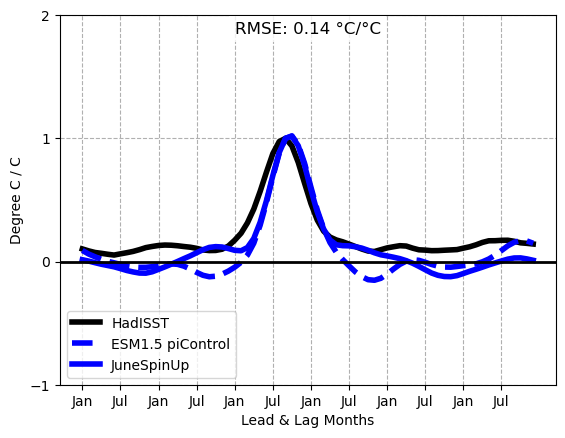

In [13]:
months = np.arange(1, 73) - 36

# Plot the slope
plt.plot(months, obs, label='HadISST', lw=4,color='black')
plt.plot(months, ctrlmodel, label='ESM1.5 piControl', lw=4,color='blue',linestyle='--')
plt.plot(months, model, label='JuneSpinUp', lw=4,color='blue')

# Draw a black dashed line at y=0.25
# plt.axhline(y=0.25, color='black', linestyle='--', label='0.25 threshold')

# Draw a thicker line at y=0
plt.axhline(y=0, color='black', linewidth=2) #, label='Zero Line')

# Define custom ticks for the x-axis (every 6 months)
xticks = np.arange(1, 73, 6) - 36  # Adjust for lead/lag months
xtick_labels = ['Jan', 'Jul'] * (len(xticks) // 2)

# Set the labels and titles
plt.xlabel('Lead & Lag Months')
plt.ylabel('Degree C / C')
plt.legend()
plt.grid(linestyle='--')

# Apply the custom ticks and labels to the x-axis
plt.xticks(xticks, xtick_labels)
plt.yticks(np.arange(-1,2.5, step=1))

# Adding RMSE text on top of the plot
plt.text(0.5, 0.95, f'RMSE: {rmse:.2f} °C/°C', fontsize=12, ha='center', transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
# Show the plot
plt.show()

Figure 1: Temporal evolution of DMI, illustrating the IOD-associated variability. The model tends to exhibit overly frequent transitions between negative and positive SSTA phases. The black curve represents the reference data, while the blue curve corresponds to the model output. The derived metric is the temporal root mean square error (RMSE) between the model and reference curves.

# Diagnostic Level 2
The second level shows the broader picture to better understand the spatial-temporal pattern of IOD: the Hovmöller of the anomalies in the equatorial Indian Ocean.

In [14]:
def sep_and_years(dmi_cube):

    dmi_sep = extract_month(dmi_cube, 9)
    leadlagyr = 3
    dmi_sep_years = [dmi_sep.coord('time').units.num2date(time).year
                     for time in dmi_sep.coord('time').points]
    event_years = dmi_sep_years[leadlagyr:-leadlagyr]
    # Ensure that the selected years are not the last years
    return dmi_sep, event_years

def sst_regressed_2d(event_years, dmi_area, dmi_sep):
    """Regression function for sst_time_series area on sst_enso."""
    dmi_area_selected = []    
    for yr in event_years:
        enso_epoch = [yr - 2, yr - 1, yr, yr + 1, yr + 2, yr + 3]
        year_enso = iris.Constraint(time=lambda cell: cell.point.year in enso_epoch)

        dmi_area_selected.append(dmi_area.extract(year_enso).data)
        
    event_constr = iris.Constraint(time=lambda cell: cell.point.year in event_years)
    dmi_sep_ct = dmi_sep.extract(event_constr)
    print(f'{len(event_years)} years, cube meri:{dmi_area.shape}')
    
    #2 area linear regression
    b_data = dmi_sep_ct.data
    b_with_intercept = np.vstack([b_data, np.ones_like(b_data)]).T
    a_arr = np.array(dmi_area_selected)
    a_data = a_arr.reshape(a_arr.shape[0], -1)
    
    print(a_arr.shape, a_data.shape, b_data.shape)
    coefs_area, _, _, _ = np.linalg.lstsq(b_with_intercept, a_data, rcond=None)
    slope_area = coefs_area[0].reshape(a_arr.shape[1], a_arr.shape[2])
    
    return slope_area

In [ ]:
ctrlmod_sep, ctrlmod_years = sep_and_years(model_ctrldmi)
ctrlmodel_area = sst_regressed_2d(ctrlmod_years, model_ctrldmi_area, ctrlmod_sep)

mod_sep, mod_years = sep_and_years(model_dmi)
model_area = sst_regressed_2d(mod_years, model_dmi_area, mod_sep)

#print(model_area.shape, datetime.now())

193 years, cube meri:(2392, 360)
(193, 72, 360) (193, 25920) (193,)


In [ ]:
obs_sep, obs_years = sep_and_years(obs_dmi)
obs_area = sst_regressed_2d(obs_years, obs_dmi_area, obs_sep)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define custom ticks for the y-axis (every 6 months)
yticks = range(1, 73, 6)
ytick_labels = ['Jan', 'Jul'] * (len(yticks) // 2)

# Define shared color limits and colorbar ticks
vmin = -1.2
vmax = 1.2
ticks = np.arange(vmin, vmax + 0.2, 0.2)  # Ticks from -1.2 to 1.2 at intervals of 0.2

# Create the subplots
fig, (ax1, ax2,ax3) = plt.subplots(1, 3, figsize=(9, 12), sharey=True)

# First subplot: HadISST
c1 = ax1.contourf(
    obs_dmi_area.coord('longitude').points,
    range(1, 73),
    obs_area, #area
    levels=np.linspace(vmin, vmax, 14),
    cmap='RdBu_r',
    extend='both'  # Allow for values beyond vmin and vmax
)
ax1.set_ylabel('Months')
ax1.set_xlabel('Longitude')
ax1.set_xlim([160, 280])
ax1.set_title('HadISST')#: reg(ENSO SSTA, SSTA)')
ax1.set_yticks(yticks)
ax1.set_yticklabels(ytick_labels)

# Second subplot: picontrol
c3 = ax2.contourf(
    model_ctrldmi_area.coord('longitude').points,
    range(1, 73),
    ctrlmodel_area,
    levels=np.linspace(vmin, vmax, 14),
    cmap='RdBu_r',
    extend='both'  # Allow for values beyond vmin and vmax
)
ax2.set_xlabel('Longitude')
ax2.set_title('ESM1.5 piControl')#: reg(ENSO SSTA, SSTA)')
ax2.set_xlim([160, 280])

# third subplot: Model
c3 = ax3.contourf(
    model_dmi_area.coord('longitude').points,
    range(1, 73),
    model_area.T,
    levels=np.linspace(vmin, vmax, 14),
    cmap='RdBu_r',
    extend='both'  # Allow for values beyond vmin and vmax
)
ax3.set_xlabel('Longitude')
ax3.set_title('JuneSpinUp')#: reg(ENSO SSTA, SSTA)')
ax3.set_xlim([160, 280])

# Adjust the layout to add space for the colorbar
fig.subplots_adjust(bottom=0.15, right=1.0)  # Adjust bottom margin to fit colorbar

# Add a horizontal colorbar beneath the subplots
cbar = fig.colorbar(c1, ax=[ax1, ax2,ax3], label='Regression (°C / °C)', orientation='horizontal', ticks=ticks, fraction=0.05, pad=0.08)

# Display the plot
plt.show()
#plt.show()

Figure 2: spatial-temporal structure of SSTas in the equatorial Indian Ocean (10°S-10°N average), showing usually the too frequent swing from negative to positive SSTA, along with maximum anomalies during iod peak lasting too long. The left and right Hovmöllers show respectively the reference and the model.